<a href="https://colab.research.google.com/github/ajaygiri7517/practicals/blob/main/Projects.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

water_potability.csv already exists.
First 5 rows:
         ph    Hardness        Solids  Chloramines     Sulfate  Conductivity  \
0       NaN  204.890455  20791.318981     7.300212  368.516441    564.308654   
1  3.716080  129.422921  18630.057858     6.635246         NaN    592.885359   
2  8.099124  224.236259  19909.541732     9.275884         NaN    418.606213   
3  8.316766  214.373394  22018.417441     8.059332  356.886136    363.266516   
4  9.092223  181.101509  17978.986339     6.546600  310.135738    398.410813   

   Organic_carbon  Trihalomethanes  Turbidity  Potability  
0       10.379783        86.990970   2.963135           0  
1       15.180013        56.329076   4.500656           0  
2       16.868637        66.420093   3.055934           0  
3       18.436524       100.341674   4.628771           0  
4       11.558279        31.997993   4.075075           0  

Missing values:
ph                 491
Hardness             0
Solids               0
Chloramines          0

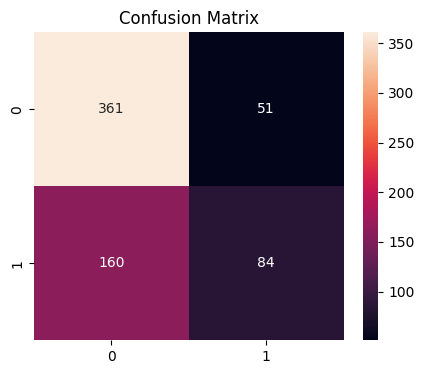


Water is NOT SAFE to drink


In [4]:
# ===============================
# Water Quality Prediction Project
# ===============================

# 1. Install libraries (Colab usually has them)
!pip install -q scikit-learn

# 2. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 3. Load dataset
# Check if the file exists, if not, download it.
import os
if not os.path.exists('water_potability.csv'):
    print("Downloading water_potability.csv...")
    !wget https://raw.githubusercontent.com/plotly/datasets/master/water_potability.csv
    # Verify download after attempting it
    if not os.path.exists('water_potability.csv'):
        raise FileNotFoundError("Failed to download 'water_potability.csv'. Please check the URL or network connection.")
else:
    print("water_potability.csv already exists.")

df = pd.read_csv("water_potability.csv")

print("First 5 rows:")
print(df.head())

# 4. Check missing values
print("\nMissing values:")
print(df.isnull().sum())

# 5. Fill missing values with mean
df.fillna(df.mean(), inplace=True)

# 6. Split features & label
X = df.drop("Potability", axis=1)
y = df["Potability"]

# 7. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 8. Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==================================
# Model 1: Logistic Regression
# ==================================

lr = LogisticRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("\nLogistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

# ==================================
# Model 2: Random Forest (Better)
# ==================================

rf = RandomForestClassifier(n_estimators=200)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("\nRandom Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

# ==================================
# Evaluation
# ==================================

print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

# ==================================
# Manual Prediction
# ==================================

sample = X_test[0].reshape(1,-1)
result = rf.predict(sample)

if result[0] == 1:
    print("\nWater is SAFE to drink")
else:
    print("\nWater is NOT SAFE to drink")